In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

c:\Users\welcome\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\welcome\.cache\kagglehub\datasets\suchintikasarkar\sentiment-analysis-for-mental-health\versions\1


In [3]:
import pandas as pd
import os


# List files inside dataset folder
print("\nFiles in dataset folder:")
print(os.listdir(path))

# Load CSV file
csv_file = os.path.join(path, "Combined Data.csv")

df = pd.read_csv(csv_file)

# Print first 5 rows
print("\nDataset Preview:")
print(df.head())


Files in dataset folder:
['Combined Data.csv']

Dataset Preview:
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


AI-Based Mental Health Sentiment Monitoring System
 
Problem Statement
A mental wellness startup wants to build an AI-powered system that can analyze user text messages and identify emotional sentiment patterns.
The goal is to:
monitor emotional well-being
identify negative sentiment trends
assist counselors with early intervention
The company wants an AI application that:
accepts user text input
predicts emotional sentiment
displays confidence score
provides emotional status feedback
You are hired as an AI Engineer to build and deploy a Simple RNN-based Mental Health Sentiment Monitoring System.
Objective
Build a Simple RNN model that classifies emotional sentiment from text messages.
 
Task 1 — Dataset Understanding


Analyze:

number of sentiment classes

text distribution

class imbalance

average sentence length

In [4]:
print(df['status'].unique())
print(df['status'].nunique())

['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']
7


In [5]:
df['sentence_length'] = df['statement'].apply(
    lambda x: len(str(x).split())
)

print(df['sentence_length'].describe())

count    53043.000000
mean       112.393285
std        163.436684
min          1.000000
25%         15.000000
50%         61.000000
75%        147.500000
max       6300.000000
Name: sentence_length, dtype: float64


In [6]:
print(df['status'].value_counts())

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


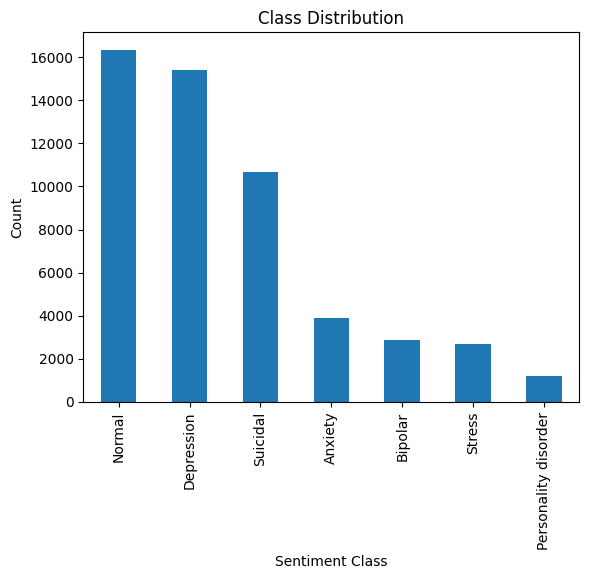

In [7]:
import matplotlib.pyplot as plt
df['status'].value_counts().plot(kind='bar')

plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.title("Class Distribution")

plt.show()

In [8]:
avg_length = df['sentence_length'].mean()

print("Average Sentence Length:", avg_length)

Average Sentence Length: 112.39328469355051


Task 2 - Text Preprocessing

Perform:

lowercase conversion

punctuation removal

stopword removal

tokenization

padding

vocabulary generation

In [9]:
df['clean_text'] = df['statement'].str.lower()

In [10]:
import re

df['clean_text'] = df['clean_text'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', str(x))
)

In [11]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\welcome\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['clean_text'] = df['clean_text'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [14]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 40

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

In [15]:
word_index = tokenizer.word_index

vocab_size = len(word_index) + 1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 74620


Task 3 - Sequence Preparation

Convert text into numerical sequences using:

Tokenizer

word indexing

padded sequences

Explain:

Why RNN cannot directly understand raw text.

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(df['clean_text'])

In [17]:
word_index = tokenizer.word_index

print(word_index)
vocab_size = len(word_index) + 1

print(vocab_size)

{'like': 1, 'feel': 2, 'want': 3, 'know': 4, 'life': 5, 'get': 6, 'im': 7, 'even': 8, 'time': 9, 'would': 10, 'people': 11, 'really': 12, 'cannot': 13, 'one': 14, 'going': 15, 'think': 16, 'go': 17, 'much': 18, 'never': 19, 'day': 20, 'help': 21, 'dont': 22, 'things': 23, 'could': 24, 'years': 25, 'anymore': 26, 'back': 27, 'anxiety': 28, 'work': 29, 'anything': 30, 'still': 31, 'make': 32, 'something': 33, 'depression': 34, 'friends': 35, 'got': 36, 'always': 37, 'good': 38, 'take': 39, 'anyone': 40, 'feeling': 41, 'way': 42, 'everything': 43, 'ive': 44, 'better': 45, 'every': 46, 'need': 47, 'see': 48, 'nothing': 49, 'someone': 50, 'also': 51, 'bad': 52, 'year': 53, 'since': 54, 'family': 55, 'right': 56, 'last': 57, 'hate': 58, 'thing': 59, 'live': 60, 'job': 61, 'fucking': 62, 'getting': 63, 'love': 64, 'end': 65, 'die': 66, 'ever': 67, 'talk': 68, 'everyone': 69, 'thought': 70, 'lot': 71, 'long': 72, 'say': 73, 'trying': 74, 'tired': 75, 'person': 76, 'started': 77, 'keep': 78, 't

In [18]:
sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)

In [19]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 40

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

Task 4 - Build Simple RNN Architecture

Students must implement:

Embedding layer

SimpleRNN layer

Dense output layer

using TensorFlow/Keras.

In [20]:
from tensorflow.keras.layers import Dense,SimpleRNN,Embedding
from tensorflow.keras.models import Sequential
model=Sequential()
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()

# Embedding layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)
num=df['status'].unique()
n=len(num)
# RNN layer
model.add(SimpleRNN(64))

# Output layer
model.add(Dense(n, activation='softmax'))

# Build model
model.build(input_shape=(None, max_length))

# Summary
model.summary()



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 40, 128)           9551360   
                                                                 
 simple_rnn (SimpleRNN)      (None, 64)                12352     
                                                                 
 dense (Dense)               (None, 7)                 455       
                                                                 
Total params: 9564167 (36.48 MB)
Trainable params: 9564167 (36.48 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Task 5 -Model Training

Train the model using:

training dataset

validation split

GPU runtime in Google Colab

Requirements:

proper batch size

epochs

learning rate tuning

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Convert text labels to integers
y = encoder.fit_transform(df['status'])

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from tensorflow.keras.optimizers import Adam


optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10


1061/1061 [==============================] - 137s 128ms/step - loss: 1.1535 - accuracy: 0.5553 - val_loss: 0.9610 - val_accuracy: 0.6014
Epoch 2/10
1061/1061 [==============================] - 141s 133ms/step - loss: 0.7444 - accuracy: 0.7167 - val_loss: 1.0076 - val_accuracy: 0.5969
Epoch 3/10
1061/1061 [==============================] - 148s 140ms/step - loss: 0.4125 - accuracy: 0.8591 - val_loss: 1.1130 - val_accuracy: 0.6034
Epoch 4/10
1061/1061 [==============================] - 136s 128ms/step - loss: 0.2245 - accuracy: 0.9295 - val_loss: 1.3254 - val_accuracy: 0.5937
Epoch 5/10
1061/1061 [==============================] - 146s 138ms/step - loss: 0.1573 - accuracy: 0.9513 - val_loss: 1.4855 - val_accuracy: 0.5786
Epoch 6/10
1061/1061 [==============================] - 158s 149ms/step - loss: 0.1411 - accuracy: 0.9558 - val_loss: 1.6226 - val_accuracy: 0.5863
Epoch 7/10
1061/1061 [==============================] - 121s 114ms/step - loss: 0.1156 - accuracy: 0.9646 - va

In [46]:
import numpy as np

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

332/332 [==============================] - 1s 4ms/step


In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5412385710246017


Task 6 - Model Evaluation

Evaluate using:

I
Accuracy
Precision
Recall
F1 Score
Confusion Matrix

In [48]:
# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert predictions to labels
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels already integer encoded
y_true = y_test

332/332 [==============================] - 1s 3ms/step


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.5412385710246017


In [50]:
print(y_test[:5])

[2 2 2 3 3]


In [51]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision:", precision)

Precision: 0.5416981585529165


In [52]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Recall:", recall)

Recall: 0.5412385710246017


In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[ 362   95   91   70   36  118    7]
 [ 149  173  103   23   34   71   27]
 [ 251  119 1396  364   66  143  761]
 [  90   21  167 2849   39  117   44]
 [  70   24   41   17   59   34    3]
 [ 141   57   77   66   30  169   17]
 [  60   26  808  287   31   72  734]]


In [54]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.32      0.46      0.38       779
           1       0.34      0.30      0.32       580
           2       0.52      0.45      0.48      3100
           3       0.78      0.86      0.81      3327
           4       0.20      0.24      0.22       248
           5       0.23      0.30      0.26       557
           6       0.46      0.36      0.41      2018

    accuracy                           0.54     10609
   macro avg       0.41      0.42      0.41     10609
weighted avg       0.54      0.54      0.54     10609



Task 7 - Sequence Understanding

You must explain:

how RNN remembers previous words

hidden state concept

sequential learning behavior



In [55]:
df

,Unnamed: 0,statement,status,sentence_length,clean_text
0,0,oh my gosh,Anxiety,3,oh gosh
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,trouble sleeping confused mind restless heart ...
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,wrong back dear forward doubt stay restless re...
3,3,I've shifted my focus to something else but I'...,Anxiety,11,ive shifted focus something else im still worried
4,4,"I'm restless and restless, it's been a month n...",Anxiety,14,im restless restless month boy mean
...,...,...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety,322,nobody takes seriously ive dealt depressionanx...
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety,198,selfishness dont feel good like dont belong wo...
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety,17,way sleep better cant sleep nights meds didnt ...
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety,74,public speaking tips hi give presentation work...


Task 8- Real-Time Prediction

Test the model using:

custom user sentences

emotional text examples

unseen sentences

In [56]:
user_text = "oh my gosh"

In [57]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Lowercase
text = user_text.lower()

# Remove punctuation
text = re.sub(r'[^a-zA-Z\s]', '', text)

# Remove stopwords
text = ' '.join(
    word for word in text.split()
    if word not in stop_words
)

In [58]:
sequence = tokenizer.texts_to_sequences([text])

In [59]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_sequence = pad_sequences(
    sequence,
    maxlen=max_length,
    padding='post'
)

In [60]:

# Prediction
prediction = model.predict(padded_sequence)

# Predicted class
predicted_class = prediction.argmax(axis=1)[0]

# Convert class number to label
predicted_label = encoder.inverse_transform(
    [predicted_class]
)[0]

# Confidence score
confidence = prediction.max()




1/1 [==============================] - 0s 34ms/step


In [61]:
# Output
print("Input Text:", user_text)

print("Predicted Emotion:", predicted_label)

print("Confidence Score:", confidence)

Input Text: oh my gosh
Predicted Emotion: Normal
Confidence Score: 0.5199927


In [62]:
print(encoder.classes_)

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [63]:
print(prediction)

[[0.2670934  0.00804764 0.1992006  0.5199927  0.00293008 0.00197457
  0.00076094]]


In [64]:
model.save("rnn_model.keras")

In [66]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [67]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [68]:
import os

print(os.listdir())

['app.py', 'label_encoder.pkl', 'requirements.txt', 'rnn_model.keras', 'Sentiment_Analysis.ipynb', 'tokenizer.pkl']
